# QSVT Sign Function and Spectral Projectors

This notebook demonstrates one of the most important matrix-function
applications of QSVT:

approximating the sign function and building spectral projectors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qsvt.polynomials import (
    chebyshev_t,
    polynomial_parity,
    is_bounded_on_interval,
)

from qsvt.matrices import rotation

from qsvt.spectral import (
    eigh_hermitian,
    positive_projector_from_sign,
    negative_projector_from_sign,
)

## 1. Chebyshev polynomials as sign approximations

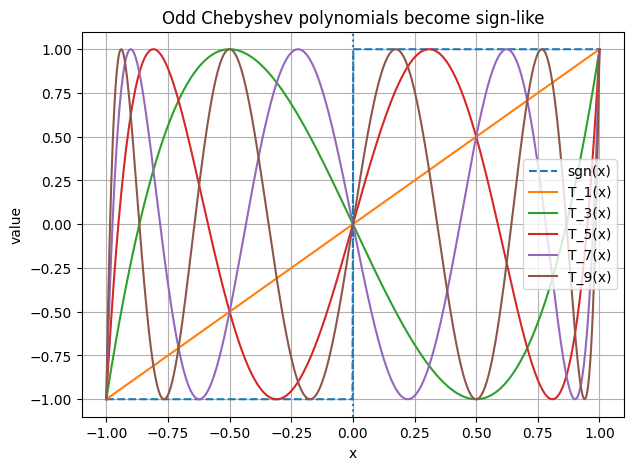

In [2]:
x = np.linspace(-1, 1, 600)

plt.figure(figsize=(7,5))

plt.plot(x, np.sign(x), "--", label="sgn(x)")

for n in [1,3,5,7,9]:

    plt.plot(
        x,
        chebyshev_t(n, x),
        label=f"T_{n}(x)"
    )

plt.axvline(0, linestyle=":")

plt.xlabel("x")
plt.ylabel("value")

plt.title("Odd Chebyshev polynomials become sign-like")

plt.grid(True)
plt.legend()

plt.show()

In [3]:
poly_T3 = np.array([0, -3, 0, 4], dtype=float)

print("parity:", polynomial_parity(poly_T3))

print(
    "bounded:",
    is_bounded_on_interval(
        poly_T3,
        lower=-1,
        upper=1,
        bound=1
    )
)

parity: odd
bounded: True


## 2. Projector behaviour in diagonal basis

In [4]:
a = 0.5

A_diag = np.diag([-a, a])
b = np.array([1.0, 1.0], dtype=float)


def projector_plus_from_chebyshev_degree(n, a, b):
    eigs = np.array([-a, a], dtype=float)
    P_vals = chebyshev_t(n, eigs)
    proj_factors = 0.5 * (1.0 + P_vals)
    return proj_factors * b


for n in [1, 3, 5, 7, 9]:
    out = projector_plus_from_chebyshev_degree(n, a, b)
    outn = out / np.linalg.norm(out)
    print(f"degree {n:2d} →", np.round(outn, 6))

degree  1 → [0.316228 0.948683]
degree  3 → [1. 0.]
degree  5 → [0.316228 0.948683]
degree  7 → [0.316228 0.948683]
degree  9 → [1. 0.]


## 3. Rotated matrix example

In [5]:
theta = 0.7

U = rotation(theta)
A = U @ A_diag @ U.T

evals, evecs = eigh_hermitian(A)

print("A =")
print(np.round(A, 6))

print("\neigenvalues =", np.round(evals, 6))

A =
[[-0.084984 -0.492725]
 [-0.492725  0.084984]]

eigenvalues = [-0.5  0.5]


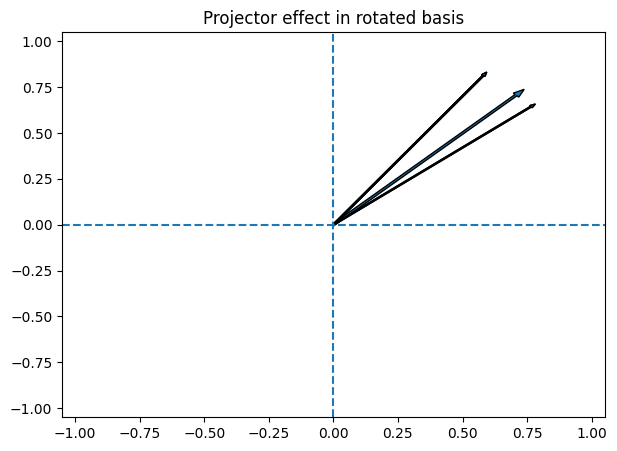

In [6]:
def projector_plus_general_chebyshev_degree(n, A, b):
    evals, evecs = eigh_hermitian(A)
    coeffs = evecs.T @ b
    P_vals = chebyshev_t(n, evals)
    proj_factors = 0.5 * (1.0 + P_vals)
    coeffs_out = proj_factors * coeffs
    return evecs @ coeffs_out


b2 = np.array([1.0, 1.0], dtype=float)

plt.figure(figsize=(7, 5))

b2n = b2 / np.linalg.norm(b2)
plt.arrow(0, 0, b2n[0], b2n[1], width=0.01)

for n in [1, 3, 5, 7, 9]:
    out = projector_plus_general_chebyshev_degree(n, A, b2)
    outn = out / np.linalg.norm(out)
    plt.arrow(0, 0, outn[0], outn[1], width=0.005)

plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Projector effect in rotated basis")
plt.show()

## 4. Using spectral helpers directly

In [7]:
Pi_plus = positive_projector_from_sign(A)
Pi_minus = negative_projector_from_sign(A)

print("positive projector:")
print(np.round(Pi_plus, 6))

print("\nnegative projector:")
print(np.round(Pi_minus, 6))

positive projector:
[[ 0.415016 -0.492725]
 [-0.492725  0.584984]]

negative projector:
[[0.584984 0.492725]
 [0.492725 0.415016]]


## Summary

sign-like polynomials produce spectral filters

projectors arise naturally from sign(A)

QSVT implements these polynomial spectral transforms